# GRUPO 43 — Proyecto Aprendizaje de Máquina 2026-20

# Clasificación de sentimiento en reseñas de productos en español

**Parte 1: Machine Learning clásico — Entrega 2 (ingeniería de características por posición)**

En la entrega 1 construimos un pipeline TF‑IDF + regresión logística que obtuvo un F1 macro de **0.74** en Kaggle. El análisis de errores mostró dos cosas:

1. La clase `neutral` ya estaba prácticamente resuelta (F1 ≈ 0.99).
2. Casi todos los errores eran confusiones entre `positivo` y `negativo` en reseñas **mixtas**, que contienen un elogio y una queja a la vez. En esas reseñas, la opinión que decide la clase es la que aparece **al final**.

La bolsa de palabras no sabe en qué parte del texto está cada palabra, así que no puede aprovechar ese patrón. En esta entrega atacamos esa limitación con **ingeniería de características**: además del TF‑IDF del texto completo, construimos un TF‑IDF aparte **solo para la última oración** y concatenamos ambas representaciones. Así el modelo puede aprender que una palabra negativa al final pesa distinto a la misma palabra al inicio.

Seguimos dentro de las reglas de la Parte 1: solo BoW / TF‑IDF / n‑gramas y clasificadores de scikit-learn, sin redes neuronales ni *embeddings* preentrenados.

## Resumen de cambios respecto a la entrega 1

| Cambio | Entrega 1 | Entrega 2 | Por qué |
|---|---|---|---|
| Representación | TF‑IDF del texto completo | TF‑IDF del texto completo **+** TF‑IDF de la última oración | El sentimiento global lo decide la última opinión. |
| n‑gramas | Solo unigramas | Se vuelven a evaluar `(1,1)` y `(1,2)` | Con la nueva representación los bigramas podrían volver a ayudar (p. ej. `aun asi`, `no funciona`). |
| Pipeline | La limpieza se aplicaba fuera del modelo guardado | Limpieza, separación de oraciones y vectorización van **dentro** de un único `Pipeline` | El `.joblib` recibe el texto crudo y predice directamente: más fácil de replicar. |
| Validación | Hold-out 80/20 + `GridSearchCV` | Igual | Mantener comparabilidad con la entrega 1. |

**Validación de nuestra validación:** en la entrega 1 obtuvimos 0.754 en validación local y 0.74 en Kaggle. Como ambos valores son muy cercanos, confiamos en que la partición local estima bien el resultado en el *leaderboard*.

## Reglas que seguimos

- `train.csv` se usa para entrenamiento y validación local.
- `eval.csv` **no** se usa para entrenar, ajustar hiperparámetros ni escoger modelos; solo se usa al final para generar la *submission*.
- No se usan redes neuronales, transformers ni *embeddings* preentrenados. Toda la representación es BoW / TF‑IDF / n‑gramas y todos los clasificadores son de scikit-learn.
- Semillas fijas (`RANDOM_STATE = 42`) y la misma partición de la entrega 1, para que los resultados sean replicables y comparables.

## 1. Preparación del entorno

In [1]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 220)

RANDOM_STATE = 42
DATA_DIR = Path("../data")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)
ORDER = ["negativo", "neutral", "positivo"]

## 2. Carga y verificación de los datos

In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
eval_df = pd.read_csv(DATA_DIR / "eval.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")

assert {"id", "text", "label"}.issubset(train_df.columns)
assert {"id", "text"}.issubset(eval_df.columns)
assert (eval_df["id"].values == sample_sub["id"].values).all()
assert train_df.isna().sum().sum() == 0 and eval_df.isna().sum().sum() == 0

print("train:", train_df.shape, "| eval:", eval_df.shape)
print(train_df["label"].value_counts().reindex(ORDER).to_dict())

train: (12000, 3) | eval: (3000, 2)
{'negativo': 4212, 'neutral': 3576, 'positivo': 4212}


La exploración completa (clases, longitudes, tildes) está en el notebook de la entrega 1. Aquí nos enfocamos en la hipótesis nueva.

## 3. Hipótesis: la última oración decide el sentimiento

### 3.1 Estructura de las reseñas

Primero separamos cada reseña en oraciones (cortando en `.`, `!` y `?`) para ver cuántas tienen.

In [3]:
def quitar_tildes(texto):
    texto = unicodedata.normalize("NFKD", texto)
    return "".join(c for c in texto if not unicodedata.combining(c))

def limpiar_texto(texto):
    # Misma limpieza de la entrega 1: minúsculas, sin tildes, solo letras
    texto = quitar_tildes(str(texto).lower())
    texto = re.sub(r"[^a-zñ\s]", " ", texto)
    return re.sub(r"\s+", " ", texto).strip()

def separar_oraciones(texto):
    partes = re.split(r"[.!?]+", str(texto))
    return [p.strip() for p in partes if limpiar_texto(p)]

train_df["oraciones"] = train_df["text"].map(separar_oraciones)
train_df["n_oraciones"] = train_df["oraciones"].str.len()
display(train_df["n_oraciones"].value_counts().sort_index().to_frame("reseñas"))

,reseñas
n_oraciones,
1,136
2,312
3,2410
4,7091
5,1950
6,99
7,2


La mayoría de reseñas tiene unas 4 oraciones. Veamos algunas reseñas positivas y negativas separadas por oración:

In [4]:
for _, r in train_df[train_df["label"] != "neutral"].sample(4, random_state=1).iterrows():
    print("=" * 100)
    print("CLASE:", r["label"].upper())
    for i, s in enumerate(r["oraciones"], 1):
        print(f"  [{i}] {s}")

CLASE: NEGATIVO
  [1] Compre esto hace un par de semanas y ya lo estoy usando en casa, en el cuarto de estar
  [2] El ensamblaje me salio resistente desde que lo estrene, no ha cedido nada con el uso diario
  [3] Aun asi, la installacion quedo mediocre para lo que cuesta
CLASE: POSITIVO
  [1] Me llego este aparato un martes, tres dias despues de haberlo pedido, justo cuando termine harto de la construccion
  [2] Lo tengo en la mesa de noche desde entonces y la caja venia con el cable y el manual
  [3] De paso, quede encantado con la duracion de la carga
CLASE: NEGATIVO
  [1] Lo pedí un martes por internet y llegó al tercer día, viene en color negro
  [2] La resistencia al agua se sintió sobresaliente al final de cuentas
  [3] Lo he traído a diario desde entonces
  [4] A fin de cuentas, el rendimiento luce ordinario hasta ahora
CLASE: NEGATIVO
  [1] Lo compré para el trabajo y llevo ya bastante tiempo usándolo
  [2] Lo pedí en una promoción, llegó en unos días, y el servicio es estupend

El patrón es consistente: las primeras oraciones hablan del envío o del uso, a veces con un elogio o una queja, y la **última** oración, muchas veces introducida por *"aun así"*, *"eso sí"*, *"a fin de cuentas"* o *"pero"*, da el juicio que define la clase.

### 3.2 Prueba rápida de la hipótesis

Antes de construir el modelo, comparamos tres representaciones con la misma regresión logística y la misma partición:

- **Texto completo** (lo de la entrega 1).
- **Solo la última oración.**
- **Texto completo + última oración** (concatenando ambos TF‑IDF).

In [5]:
train_df["text_clean"] = train_df["text"].map(limpiar_texto)
train_df["ultima_clean"] = train_df["oraciones"].map(lambda o: limpiar_texto(o[-1]) if o else "")

idx_train, idx_val = train_test_split(
    train_df.index, test_size=0.2, stratify=train_df["label"], random_state=RANDOM_STATE
)
y_train = train_df.loc[idx_train, "label"]
y_val = train_df.loc[idx_val, "label"]

def tfidf():
    return TfidfVectorizer(min_df=2, sublinear_tf=True)

def evaluar_columnas(columnas):
    ct = ColumnTransformer([(c, tfidf(), c) for c in columnas])
    modelo = Pipeline([("vec", ct), ("clf", LogisticRegression(C=10, max_iter=3000, random_state=RANDOM_STATE))])
    modelo.fit(train_df.loc[idx_train, columnas], y_train)
    pred = modelo.predict(train_df.loc[idx_val, columnas])
    return accuracy_score(y_val, pred), f1_score(y_val, pred, average="macro")

pruebas = {
    "Texto completo (entrega 1)": ["text_clean"],
    "Solo última oración": ["ultima_clean"],
    "Texto completo + última oración": ["text_clean", "ultima_clean"],
}
filas = []
for nombre, cols in pruebas.items():
    acc, f1 = evaluar_columnas(cols)
    filas.append({"representación": nombre, "accuracy": acc, "f1_macro": f1})
display(pd.DataFrame(filas).round(4))

,representación,accuracy,f1_macro
0,Texto completo (entrega 1),0.7421,0.7535
1,Solo última oración,0.8550,0.8581
2,Texto completo + última oración,0.8812,0.8865


**Lectura:** la hipótesis se confirma con claridad.

- La **última oración sola** ya supera al texto completo por más de 10 puntos de F1. Con menos palabras el modelo predice mejor, porque eliminamos las opiniones "distractoras" del inicio.
- **Combinar ambas** representaciones es lo mejor. El texto completo sigue aportando: por ejemplo, para reconocer reseñas neutrales, cuyo vocabulario descriptivo está repartido en todo el texto, o cuando la última oración no trae el juicio.

Es un buen ejemplo de que la representación de los datos importa más que el clasificador: no cambiamos el modelo, solo le dimos variables que reflejan cómo se estructura el problema.

## 4. Pipeline completo

Para que el modelo guardado sea fácil de replicar, metemos todo en un único `Pipeline` de scikit-learn que recibe el **texto crudo**:

1. `FunctionTransformer(construir_vistas)`: convierte cada reseña en dos columnas, el texto completo limpio y la última oración limpia.
2. `ColumnTransformer`: aplica un `TfidfVectorizer` **independiente** a cada columna (cada uno con su propio vocabulario) y concatena las matrices.
3. Clasificador.

In [6]:
def construir_vistas(textos):
    textos = pd.Series(textos).astype(str)
    oraciones = textos.map(separar_oraciones)
    return pd.DataFrame({
        "completo": textos.map(limpiar_texto).values,
        "ultima": oraciones.map(lambda o: limpiar_texto(o[-1]) if o else "").values,
    })

def crear_pipeline(clf):
    return Pipeline([
        ("vistas", FunctionTransformer(construir_vistas)),
        ("tfidf", ColumnTransformer([
            ("completo", TfidfVectorizer(min_df=2, sublinear_tf=True), "completo"),
            ("ultima", TfidfVectorizer(min_df=2, sublinear_tf=True), "ultima"),
        ])),
        ("clf", clf),
    ])

X_train = train_df.loc[idx_train, "text"]
X_val = train_df.loc[idx_val, "text"]
print(construir_vistas(X_train.head(2)).to_string())

                                                                                                                                                                                                      completo                                           ultima
0  lo compre hace un par de meses por internet y llego en tres dias desde que llego lo uso para el gimnasio la carga se hace con un conector magnetico por un puerto propio por cierto trae garantia de un ano               por cierto trae garantia de un ano
1                                                                              hace unos dias lo uso a diario la verdad el material me reslto optimo la verdad con todo el material se ve defectuoso la verdad  con todo el material se ve defectuoso la verdad


## 5. Comparación de clasificadores con la nueva representación

Como en la entrega 1, comparamos Naive Bayes multinomial y regresión logística, ahora sobre la representación combinada.

In [7]:
candidatos = {
    "Naive Bayes": MultinomialNB(),
    "Regresión logística": LogisticRegression(C=10, max_iter=3000, random_state=RANDOM_STATE),
}
filas = []
for nombre, clf in candidatos.items():
    m = crear_pipeline(clf).fit(X_train, y_train)
    p = m.predict(X_val)
    filas.append({"modelo": nombre, "accuracy": accuracy_score(y_val, p), "f1_macro": f1_score(y_val, p, average="macro")})
display(pd.DataFrame(filas).round(4))

,modelo,accuracy,f1_macro
0,Naive Bayes,0.8771,0.8819
1,Regresión logística,0.8812,0.8865


Con la nueva representación, ambos modelos quedan muy cerca: la mejora no depende del clasificador. Escogemos la regresión logística porque queda ligeramente arriba y porque permite interpretar los coeficientes, y ajustamos sus hiperparámetros.

## 6. Ajuste de hiperparámetros con validación cruzada

Buscamos con `GridSearchCV` (5 *folds* estratificados, métrica F1 macro):

- `C` de la regresión logística: fuerza de la regularización.
- `ngram_range` de **cada** vectorizador por separado. En la entrega 1 los bigramas no ayudaron, pero en la última oración podrían capturar construcciones como *"no me"* o *"de maravilla"*.

In [8]:
pipeline = crear_pipeline(LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))

param_grid = {
    "tfidf__completo__ngram_range": [(1, 1), (1, 2)],
    "tfidf__ultima__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [1, 10, 30],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipeline, param_grid, scoring="f1_macro", cv=cv, n_jobs=-1, return_train_score=True)
grid.fit(X_train, y_train)

cv_res = pd.DataFrame(grid.cv_results_)[[
    "param_tfidf__completo__ngram_range", "param_tfidf__ultima__ngram_range", "param_clf__C",
    "mean_train_score", "mean_test_score", "std_test_score",
]].sort_values("mean_test_score", ascending=False).round(4)
cv_res.columns = ["ngram completo", "ngram última", "C", "F1 train", "F1 CV", "desv CV"]
display(cv_res)
print("Mejores hiperparámetros:", grid.best_params_)
print(f"F1 macro promedio en CV: {grid.best_score_:.4f}")

,ngram completo,ngram última,C,F1 train,F1 CV,desv CV
2,"(1, 2)","(1, 1)",1,0.9650,0.8854,0.0125
10,"(1, 2)","(1, 1)",30,1.0000,0.8844,0.0094
6,"(1, 2)","(1, 1)",10,0.9993,0.8842,0.0099
0,"(1, 1)","(1, 1)",1,0.9433,0.8827,0.0104
7,"(1, 2)","(1, 2)",10,0.9998,0.8812,0.0118
11,"(1, 2)","(1, 2)",30,1.0000,0.8796,0.0123
4,"(1, 1)","(1, 1)",10,0.9793,0.8791,0.0101
5,"(1, 1)","(1, 2)",10,0.9877,0.8774,0.0103
3,"(1, 2)","(1, 2)",1,0.9720,0.8766,0.0154
8,"(1, 1)","(1, 1)",30,0.9874,0.8741,0.0108


Mejores hiperparámetros: {'clf__C': 1, 'tfidf__completo__ngram_range': (1, 2), 'tfidf__ultima__ngram_range': (1, 1)}
F1 macro promedio en CV: 0.8854


**Lectura:**

- Todas las configuraciones quedan entre 0.87 y 0.89 de F1 en CV: la mejora viene de la **representación**, no del ajuste fino.
- Gana `C = 1`, más regularizado que en la entrega 1 (`C = 10`). Con `C = 10` o `30` el F1 de entrenamiento llega a 1.0 sin mejorar la validación cruzada: el modelo tiene el doble de variables y necesita más regularización para no sobreajustar.
- Los bigramas ayudan en el **texto completo** pero no en la **última oración**. Una explicación posible es que la última oración es corta y sus bigramas son demasiado escasos para estimarse bien.

## 7. Evaluación en validación

Accuracy validación: 0.8892
F1 macro validación: 0.8935

              precision    recall  f1-score   support

    negativo     0.8504    0.8493    0.8499       843
     neutral     0.9727    0.9958    0.9841       715
    positivo     0.8547    0.8385    0.8465       842

    accuracy                         0.8892      2400
   macro avg     0.8926    0.8945    0.8935      2400
weighted avg     0.8883    0.8892    0.8887      2400



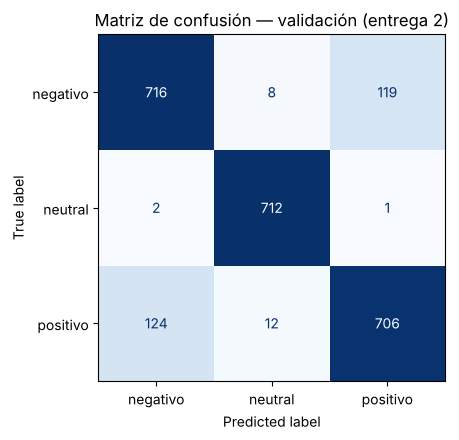

In [9]:
mejor_modelo = grid.best_estimator_
pred_val = mejor_modelo.predict(X_val)

print(f"Accuracy validación: {accuracy_score(y_val, pred_val):.4f}")
print(f"F1 macro validación: {f1_score(y_val, pred_val, average='macro'):.4f}")
print()
print(classification_report(y_val, pred_val, digits=4))

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_val, pred_val, labels=ORDER, cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Matriz de confusión — validación (entrega 2)")
plt.tight_layout()
plt.show()

### 7.1 Comparación con la entrega 1

,Entrega 1,Entrega 2
negativo,0.6351,0.8499
neutral,0.9882,0.9841
positivo,0.6371,0.8465
F1 macro,0.7535,0.8935
accuracy,0.7421,0.8892


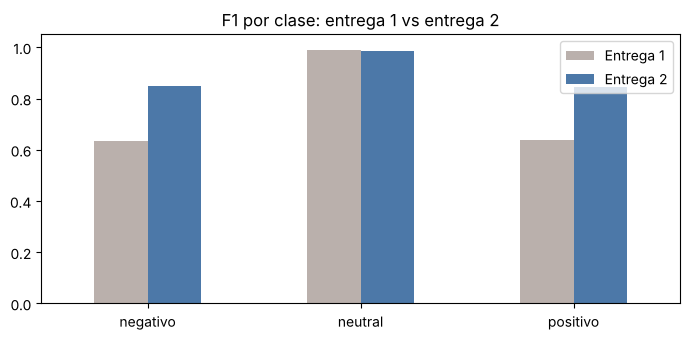

In [10]:
base = Pipeline([
    ("vec", TfidfVectorizer(min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(C=10, max_iter=3000, random_state=RANDOM_STATE)),
]).fit(train_df.loc[idx_train, "text_clean"], y_train)
pred_base = base.predict(train_df.loc[idx_val, "text_clean"])

comp = pd.DataFrame({
    "Entrega 1": f1_score(y_val, pred_base, average=None, labels=ORDER),
    "Entrega 2": f1_score(y_val, pred_val, average=None, labels=ORDER),
}, index=ORDER)
comp.loc["F1 macro"] = [f1_score(y_val, pred_base, average="macro"), f1_score(y_val, pred_val, average="macro")]
comp.loc["accuracy"] = [accuracy_score(y_val, pred_base), accuracy_score(y_val, pred_val)]
display(comp.round(4))

comp.loc[ORDER].plot(kind="bar", figsize=(7, 3.5), color=["#BAB0AC", "#4C78A8"])
plt.title("F1 por clase: entrega 1 vs entrega 2")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

La mejora está exactamente donde la buscábamos: `neutral` se mantiene (≈ 0.98–0.99), y el F1 de `positivo` y `negativo` sube más de 20 puntos (de ≈ 0.64 a ≈ 0.85).

### 7.2 Interpretación: términos más influyentes de la última oración

Revisamos los coeficientes de la regresión logística correspondientes **solo** al vectorizador de la última oración.

In [11]:
ct = mejor_modelo.named_steps["tfidf"]
clf = mejor_modelo.named_steps["clf"]
nombres = np.array(ct.get_feature_names_out())
mascara_ultima = np.char.startswith(nombres.astype(str), "ultima__")

top = {}
for i, clase in enumerate(clf.classes_):
    coefs = np.where(mascara_ultima, clf.coef_[i], -np.inf)
    idx = np.argsort(coefs)[::-1][:15]
    top[clase] = [n.replace("ultima__", "") for n in nombres[idx]]
display(pd.DataFrame(top))

,negativo,neutral,positivo
0,mal,viene,bien
1,pobre,trae,buena
2,inconsistente,en,resistente
3,deficiente,llego,impecable
4,debil,solo,sobresaliente
5,terrible,por,espectacular
6,torpe,pesa,decente
7,olvidable,caja,potente
8,decepcionante,he,excelente
9,endeble,contar,eficiente


Los términos más influyentes de la última oración son adjetivos de juicio (positivos para `positivo` y negativos para `negativo`). Esto confirma que el modelo usa la nueva vista para lo que esperábamos: leer la conclusión de la reseña.

## 8. Análisis de errores restantes

In [12]:
errores = pd.DataFrame({"texto": X_val, "real": y_val, "pred": pred_val})
errores = errores[errores["real"] != errores["pred"]]
print(f"Errores: {len(errores)} de {len(y_val)}")
display(pd.crosstab(errores["real"], errores["pred"]))
for _, r in errores.sample(5, random_state=RANDOM_STATE).iterrows():
    print("-" * 100)
    print(f"REAL: {r['real']} | PREDICHO: {r['pred']}")
    print(r["texto"])

Errores: 266 de 2400


pred,negativo,neutral,positivo
real,,,
negativo,0,8,119
neutral,2,0,1
positivo,124,12,0


----------------------------------------------------------------------------------------------------
REAL: positivo | PREDICHO: neutral
Llevo ya un tiempo con este monitor, lo tengo puesto en mi oficina desde que llego, tardo unos cuatro dias en venir a mi casa. La silla dnde lo uso esta junto a la ventana. He de decir que la comodidad se ve mal construida hasta ahora, aunque al final la resolucion me resulto superior en el dia a dia. Lo conecte por el puerto HDMI que trae.
----------------------------------------------------------------------------------------------------
REAL: negativo | PREDICHO: positivo
Compré esta correa por internet porque la mía vieja ya se había roto, llegó en tres días a casa. La correa no es para nada lo que esperaba. La uso para salir a pasear con mi perro en las tardes por el parque. De paso, me encantó la velocidad de principio a fin.
----------------------------------------------------------------------------------------------------
REAL: negativo | PRED

Los errores que quedan caen en casos como estos:

- **La última oración no es el juicio**, por ejemplo una frase de cierre como *"Sopésalo tú mismo"* o un comentario de uso. Ahí la opinión decisiva está en la penúltima oración.
- **Conectores aditivos en vez de contrastivos.** Cuando la última oración empieza con *"de paso"* o *"además"*, no siempre es la conclusión; a veces la queja de una oración anterior pesa más. Nuestra regla de "la última oración manda" es una aproximación, no una ley del conjunto de datos.
- **Adjetivos ambiguos o poco frecuentes** (*"cumplidor"*, *"corriente"*, *"olvidable"*) cuyo sentido depende del contexto, o palabras con errores de tipeo que el vocabulario no reconoce.

## 9. Modelo final, predicción sobre `eval.csv` y guardado

Reentrenamos el pipeline con los mejores hiperparámetros sobre **todo** `train.csv`. Como el pipeline incluye la limpieza y la separación de oraciones, se le pasa directamente la columna `text` cruda de `eval.csv`.

In [13]:
modelo_final = crear_pipeline(LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
modelo_final.set_params(**grid.best_params_)
modelo_final.fit(train_df["text"], train_df["label"])

submission = pd.DataFrame({"id": eval_df["id"], "answer": modelo_final.predict(eval_df["text"])})

assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)
assert submission["answer"].isin(ORDER).all()

submission.to_csv("submission-G43-2.csv", index=False)
print(submission.head())
print()
print(submission["answer"].value_counts(normalize=True).round(3))

   id    answer
0   0   neutral
1   1  positivo
2   2   neutral
3   3   neutral
4   4   neutral

answer
positivo    0.360
negativo    0.354
neutral     0.286
Name: proportion, dtype: float64


El modelo se guarda completo con `joblib`. **Importante para replicar:** el pipeline usa las funciones `construir_vistas`, `separar_oraciones`, `limpiar_texto` y `quitar_tildes`, definidas en este notebook. Para cargar el `.joblib` en otro entorno, esas funciones deben estar definidas antes de llamar a `joblib.load`, por ejemplo ejecutando las celdas de las secciones 3.1 y 4.

In [14]:
ruta_modelo = MODELS_DIR / "modelo_entrega2_tfidf_ultima_oracion_logreg.joblib"
joblib.dump(modelo_final, ruta_modelo)

modelo_cargado = joblib.load(ruta_modelo)
assert (modelo_cargado.predict(eval_df["text"]) == submission["answer"]).all()
print("Modelo guardado en", ruta_modelo, "y verificado.")

Modelo guardado en models/modelo_entrega2_tfidf_ultima_oracion_logreg.joblib y verificado.


## 10. Conclusiones y próximos pasos

**Resultado:** al agregar una representación TF‑IDF de la **última oración** a la del texto completo, el F1 macro en validación pasa de **≈ 0.75** (entrega 1) a **≈ 0.89**. Toda la mejora viene de separar `positivo` y `negativo`; `neutral` se mantiene en ≈ 0.99.

**Lección principal:** la limitación de la bolsa de palabras (pierde el orden) se puede mitigar en parte con ingeniería de características que codifique **dónde** aparece cada palabra, sin salir de los modelos clásicos. Aun así, es un parche: solo distinguimos la última oración del resto. Los modelos secuenciales de la Parte 2 deberían capturar el orden de forma más general.

**Posibles mejoras siguientes (dentro de las reglas de la Parte 1):**

1. Detectar la **última oración con juicio** en lugar de la última oración a secas, por ejemplo saltando frases de cierre cortas sin adjetivos.
2. Agregar una tercera vista con la **penúltima oración** o con el texto después del último conector contrastivo (*pero, aun así, eso sí, a fin de cuentas*).
3. **n‑gramas de caracteres** (`analyzer="char_wb"`) en la última oración, para ser más robustos a errores de tipeo (*"installacion"*, *"autonoia"*).
4. Ensambles de modelos (votación entre regresión logística y Naive Bayes, Random Forest).